<a href="https://colab.research.google.com/github/Master-utsav/ML_1_Ford_Price_Prediction/blob/main/ML_1_1_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('ford.csv')
# df.head()

## Predict Price of Ford

In [ ]:
# df.shape
# df.info()
# df.isnull().sum() no null values
# df.describe()
# len(df['model'].unique())
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0


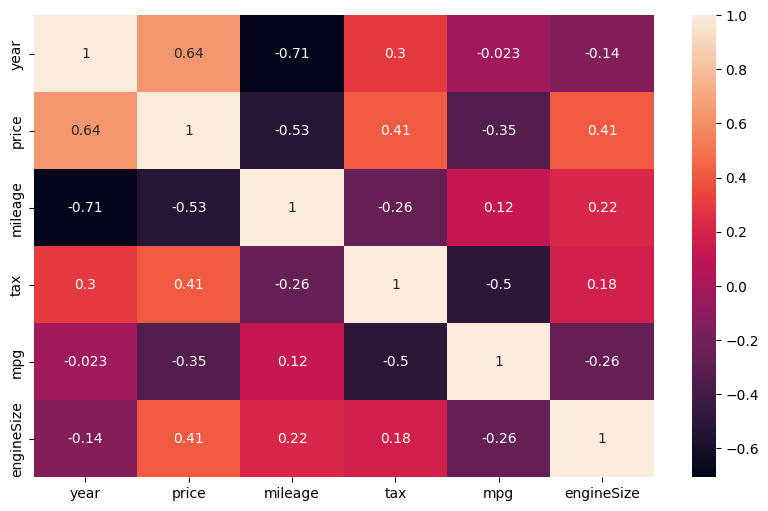

In [ ]:
# Lets check the relation of each feature with the cost
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

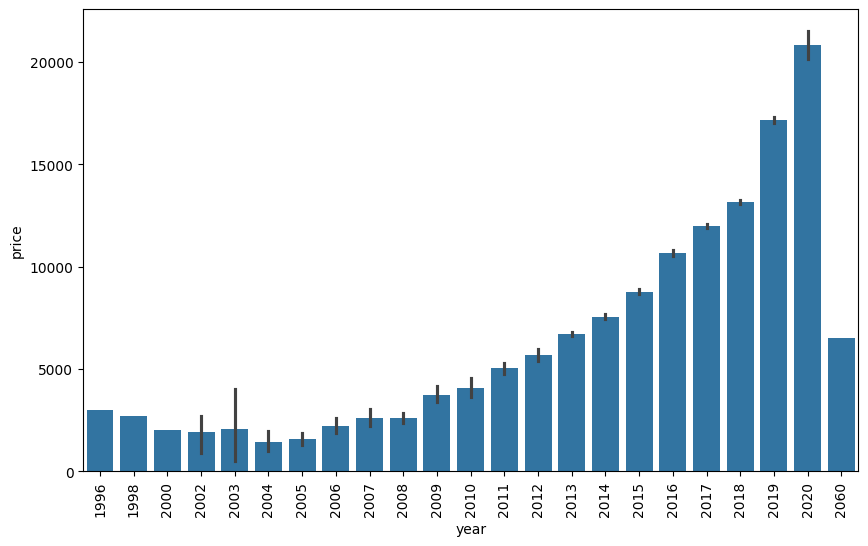

In [ ]:
# year with price lets plot the bargraph
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x=df['year'], y=df['price'])
plt.xticks(rotation=90)
plt.show()

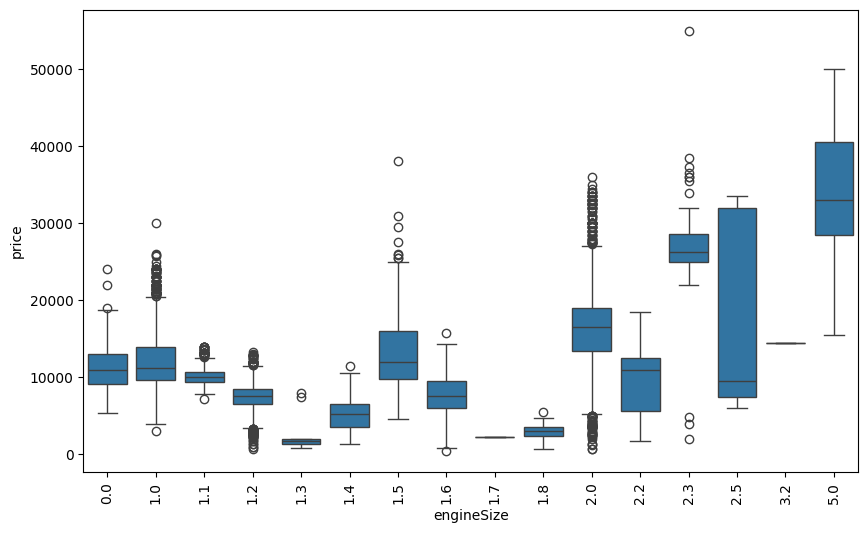

In [ ]:
# year with enginesize lets plot the bargraph
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x=df['engineSize'], y=df['price'])
plt.xticks(rotation=90)
plt.show()

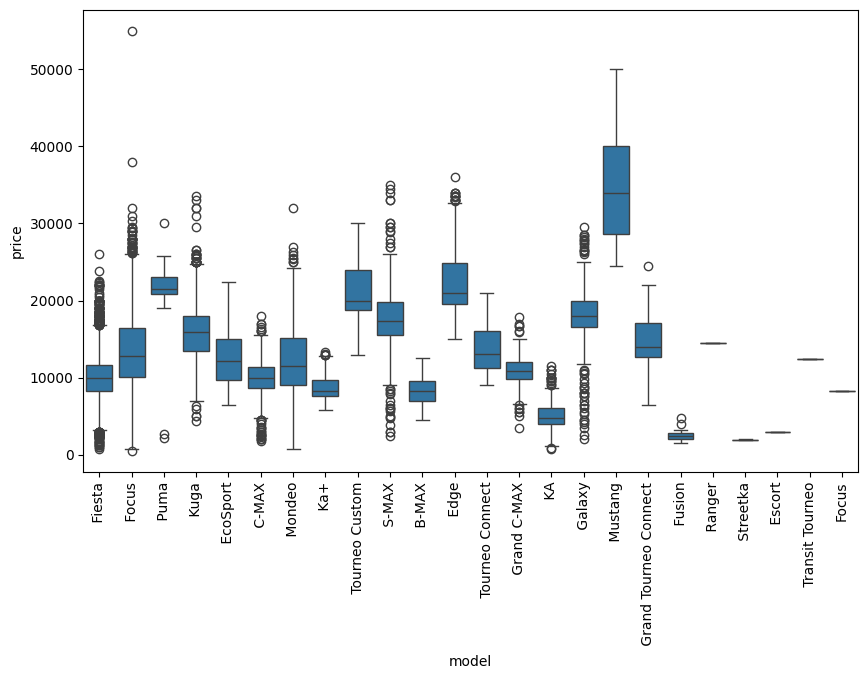

In [ ]:
# year with model lets plot the bargraph
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x=df['model'], y=df['price'])
plt.xticks(rotation=90)
plt.show()

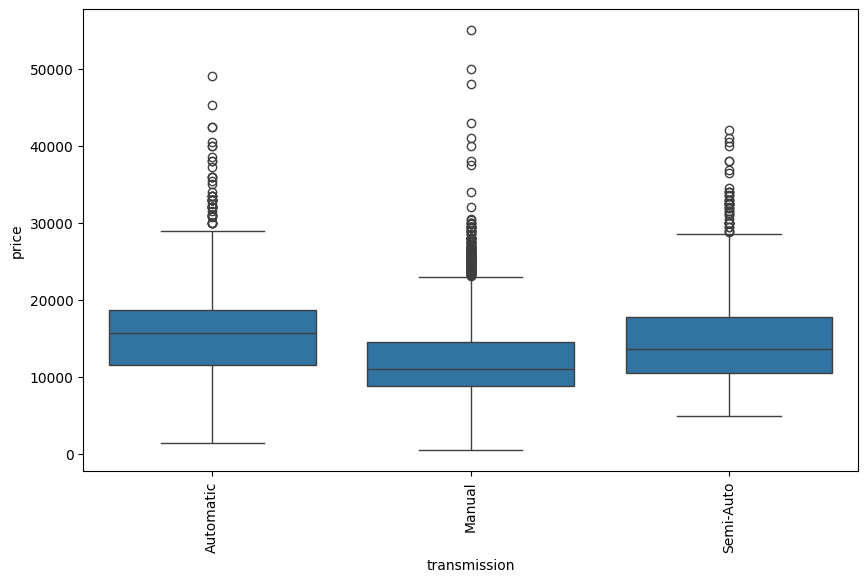

In [ ]:
# year with transmission lets plot the bargraph
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x=df['transmission'], y=df['price'])
plt.xticks(rotation=90)
plt.show()

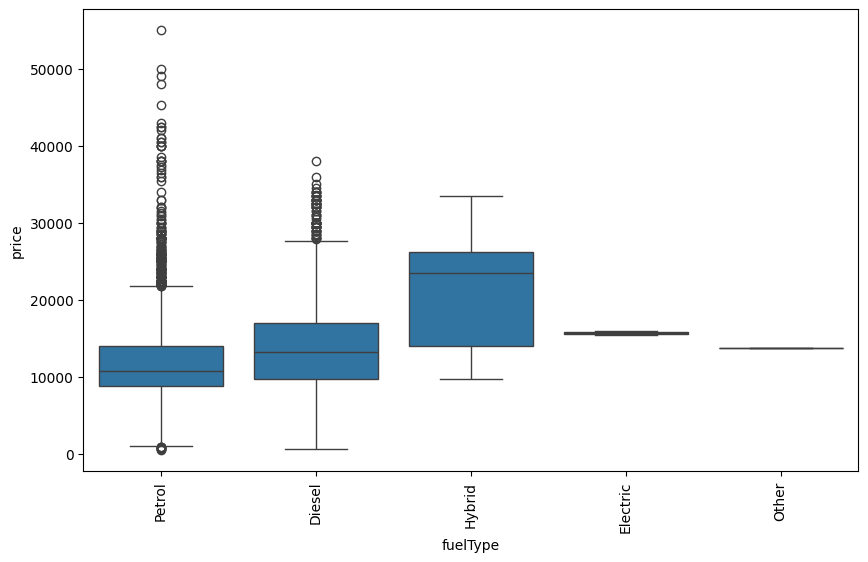

In [ ]:
# year with fuelType lets plot the bargraph
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x=df['fuelType'], y=df['price'])
plt.xticks(rotation=90)
plt.show()

In [ ]:
X = df.drop('price', axis=1)
y = df['price']

cols_to_encode = ['model', 'transmission', 'fuelType']

In [ ]:
# one hot encoded
X_one_hot_encoded = X.copy()
X_one_hot_encoded = pd.get_dummies(X_one_hot_encoded,columns=cols_to_encode).astype(int)
X_one_hot_encoded


,year,mileage,tax,mpg,engineSize,model_ B-MAX,model_ C-MAX,model_ EcoSport,model_ Edge,model_ Escort,...,model_ Transit Tourneo,model_Focus,transmission_Automatic,transmission_Manual,transmission_Semi-Auto,fuelType_Diesel,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,2017,15944,150,57,1,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,1
1,2018,9083,150,57,1,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
2,2017,12456,150,57,1,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
3,2019,10460,145,40,1,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
4,2019,1482,145,48,1,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17961,2017,16700,150,47,1,1,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
17962,2014,40700,30,57,1,1,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
17963,2015,7010,20,67,1,0,0,0,0,0,...,0,0,0,1,0,1,0,0,0,0
17964,2018,5007,145,57,1,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1


In [ ]:
# label encoded
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder();
X_label_encoded = X.copy()

for col in cols_to_encode:
    X_label_encoded[col] = encoder.fit_transform(X_label_encoded[col])
X_label_encoded


,model,year,transmission,mileage,fuelType,tax,mpg,engineSize
0,5,2017,0,15944,4,150,57.7,1.0
1,6,2018,1,9083,4,150,57.7,1.0
2,6,2017,1,12456,4,150,57.7,1.0
3,5,2019,1,10460,4,145,40.3,1.5
4,5,2019,0,1482,4,145,48.7,1.0
...,...,...,...,...,...,...,...,...
17961,0,2017,1,16700,4,150,47.1,1.4
17962,0,2014,1,40700,4,30,57.7,1.0
17963,6,2015,1,7010,0,20,67.3,1.6
17964,11,2018,1,5007,4,145,57.7,1.2


In [ ]:
# first use the standarization one hot encoding
from sklearn.preprocessing import StandardScaler

scalers = {}
numerical_cols_to_scale = ['year', 'mileage', 'tax', 'mpg', 'engineSize']
# Scaling for X_one_hot_encoded
for col in numerical_cols_to_scale:
    sc = StandardScaler()
    X_one_hot_encoded[col] = sc.fit_transform(X_one_hot_encoded[[col]])
    scalers[col] = sc

In [ ]:
import joblib

print("Final scalers keys:", scalers.keys())

joblib.dump(scalers, 'scalers.joblib')

Final scalers keys: dict_keys(['year', 'mileage', 'tax', 'mpg', 'engineSize'])


['scalers.joblib']

In [ ]:
# Scaling for X_label_encoded
for i in X_label_encoded:
    sc_le = StandardScaler()
    X_label_encoded[i] = sc_le.fit_transform(X_label_encoded[[i]])

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score


In [ ]:
# using one_hot_encoding make a model
X_train, X_test, y_train, y_test = train_test_split(X_one_hot_encoded, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
r2

0.8464177711972798

In [ ]:
# using label encoding make a model
X_train, X_test, y_train, y_test = train_test_split(X_label_encoded, y, test_size=0.2, random_state=42)
model2 = LinearRegression()
model2.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred2 = model2.predict(X_test)
r2_l = r2_score(y_test, y_pred2)
r2_l

0.7365884288851352

In [ ]:
X_one_hot_encoded.columns

Index(['year', 'mileage', 'tax', 'mpg', 'engineSize', 'model_ B-MAX',
       'model_ C-MAX', 'model_ EcoSport', 'model_ Edge', 'model_ Escort',
       'model_ Fiesta', 'model_ Focus', 'model_ Fusion', 'model_ Galaxy',
       'model_ Grand C-MAX', 'model_ Grand Tourneo Connect', 'model_ KA',
       'model_ Ka+', 'model_ Kuga', 'model_ Mondeo', 'model_ Mustang',
       'model_ Puma', 'model_ Ranger', 'model_ S-MAX', 'model_ Streetka',
       'model_ Tourneo Connect', 'model_ Tourneo Custom',
       'model_ Transit Tourneo', 'model_Focus', 'transmission_Automatic',
       'transmission_Manual', 'transmission_Semi-Auto', 'fuelType_Diesel',
       'fuelType_Electric', 'fuelType_Hybrid', 'fuelType_Other',
       'fuelType_Petrol'],
      dtype='object')

In [ ]:
scalers

{'year': StandardScaler(),
 'mileage': StandardScaler(),
 'tax': StandardScaler(),
 'mpg': StandardScaler(),
 'engineSize': StandardScaler()}

In [ ]:
import joblib
joblib.dump(model, 'ford_price_model.joblib')   # your trained model

['ford_price_model.joblib']